In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

CUDA available: True
Device name: Tesla T4


Generated 3000 samples
  water anomalies: 1518, napl anomalies: 1482
  eps_r overall range: 1.96 - 25.00
  sigma overall range: 0.00010 - 0.04997

Final dataset tensor shape: torch.Size([3000, 2, 64, 64])
Value range after normalization: -1.000 to 1.000
Saved: gpr_synthetic_dataset.pt


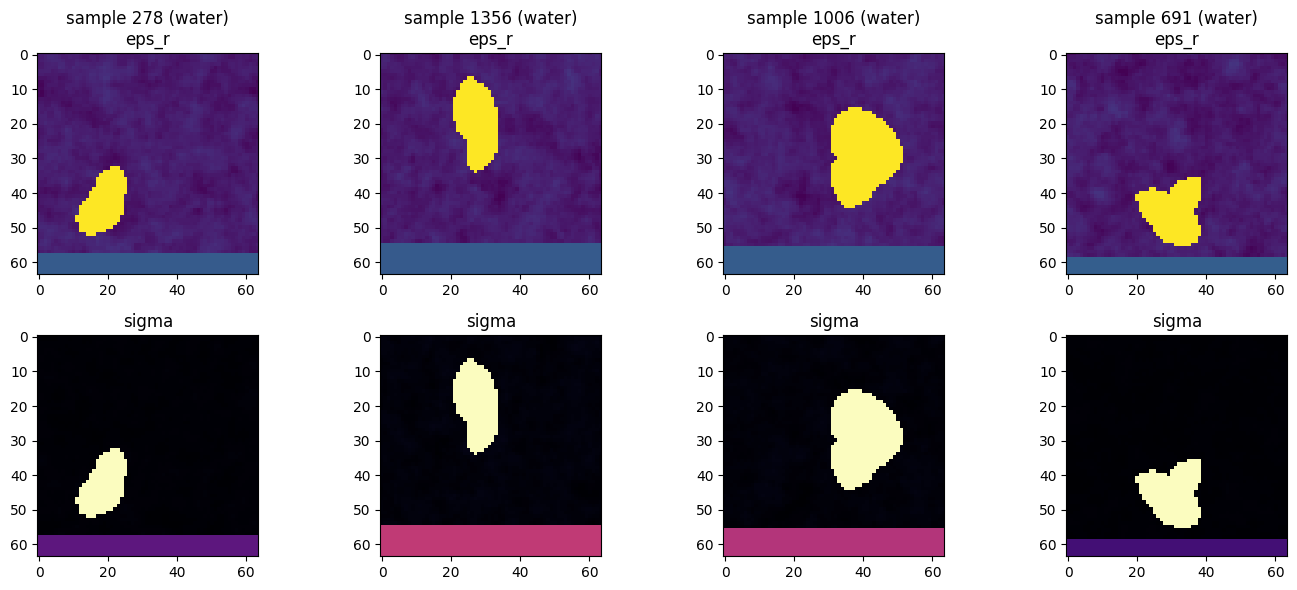

In [ ]:
import torch

N_SAMPLES = 3000
SHAPE = (64, 64)

# Physical bounds across all material states, used for normalization
EPS_MIN, EPS_MAX = 2.0, 25.0      # NAPL low end to water high end
SIG_MIN, SIG_MAX = 0.0001, 0.05   # NAPL low end to water high end

eps_all = np.zeros((N_SAMPLES, *SHAPE), dtype=np.float32)
sig_all = np.zeros((N_SAMPLES, *SHAPE), dtype=np.float32)
labels = []

for i in range(N_SAMPLES):
    eps_i, sig_i, atype = generate_sample(shape=SHAPE, seed=i)
    eps_all[i] = eps_i
    sig_all[i] = sig_i
    labels.append(atype)

print(f"Generated {N_SAMPLES} samples")
print(f"  water anomalies: {labels.count('water')}, napl anomalies: {labels.count('napl')}")
print(f"  eps_r overall range: {eps_all.min():.2f} - {eps_all.max():.2f}")
print(f"  sigma overall range: {sig_all.min():.5f} - {sig_all.max():.5f}")

# Normalize to [-1, 1] using physical bounds (not per-sample) so the
# mapping stays invertible and consistent across the whole dataset
def normalize(x, lo, hi):
    return 2 * (np.clip(x, lo, hi) - lo) / (hi - lo) - 1

eps_norm = normalize(eps_all, EPS_MIN, EPS_MAX)
sig_norm = normalize(sig_all, SIG_MIN, SIG_MAX)

# Stack into a 2-channel tensor: [N, 2, H, W] -- channel 0 = eps_r, channel 1 = sigma
dataset = np.stack([eps_norm, sig_norm], axis=1)
dataset_tensor = torch.from_numpy(dataset).float()
print(f"\nFinal dataset tensor shape: {dataset_tensor.shape}")
print(f"Value range after normalization: {dataset_tensor.min():.3f} to {dataset_tensor.max():.3f}")

torch.save(dataset_tensor, 'gpr_synthetic_dataset.pt')
print("Saved: gpr_synthetic_dataset.pt")

# Visualize a few random samples to confirm diversity
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
sample_idxs = np.random.choice(N_SAMPLES, 4, replace=False)
for col, idx in enumerate(sample_idxs):
    axes[0, col].imshow(eps_all[idx], cmap='viridis')
    axes[0, col].set_title(f'sample {idx} ({labels[idx]})\neps_r')
    axes[1, col].imshow(sig_all[idx], cmap='magma')
    axes[1, col].set_title('sigma')
plt.tight_layout()
plt.show()

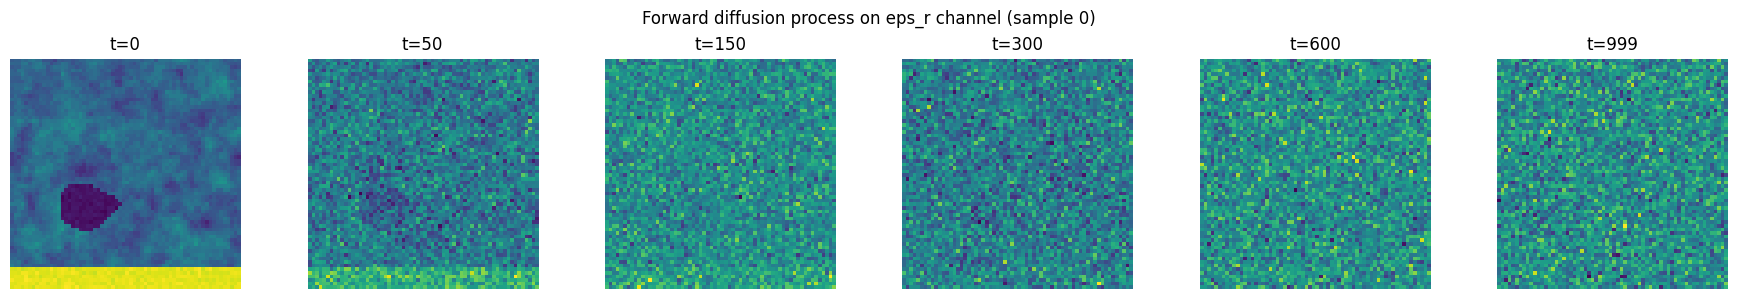

U-Net parameter count: 6,442,626


In [ ]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ---------------- U-Net building blocks ----------------

class SinusoidalPositionEmbeddings(nn.Module):
    """Standard transformer-style sinusoidal embedding for the diffusion timestep."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


class ResidualBlock(nn.Module):
    """Conv block with GroupNorm, SiLU activation, and time-embedding injection."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class SimpleUNet(nn.Module):
    """Compact U-Net for 64x64, 2-channel (eps_r, sigma) diffusion model.
    Sized to train comfortably on a single T4 GPU."""
    def __init__(self, in_ch=2, base_ch=64, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim), nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim))

        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # Downsampling path: 64 -> 32 -> 16 -> 8
        self.down1 = ResidualBlock(base_ch, base_ch, time_emb_dim)
        self.pool1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_ch, base_ch * 2, time_emb_dim)
        self.pool2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_ch * 2, base_ch * 4, time_emb_dim)
        self.pool3 = nn.Conv2d(base_ch * 4, base_ch * 4, 4, stride=2, padding=1)

        self.bottleneck = ResidualBlock(base_ch * 4, base_ch * 4, time_emb_dim)

        # Upsampling path, mirrored with skip connections
        self.up3 = nn.ConvTranspose2d(base_ch * 4, base_ch * 4, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(base_ch * 8, base_ch * 2, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(base_ch * 4, base_ch, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(base_ch * 2, base_ch, time_emb_dim)

        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 3, padding=1))

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x0 = self.in_conv(x)
        d1 = self.down1(x0, t_emb)
        d2 = self.down2(self.pool1(d1), t_emb)
        d3 = self.down3(self.pool2(d2), t_emb)
        b = self.bottleneck(self.pool3(d3), t_emb)

        u3 = self.dec3(torch.cat([self.up3(b), d3], dim=1), t_emb)
        u2 = self.dec2(torch.cat([self.up2(u3), d2], dim=1), t_emb)
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1), t_emb)

        return self.out_conv(u1)


# ---------------- Diffusion schedule (forward process) ----------------

class DiffusionSchedule:
    """Standard linear-beta DDPM schedule and forward noising process."""
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        """Forward process: sample x_t given x_0 and timestep t (closed-form, no
        need to iterate -- this is the standard DDPM reparameterization)."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_omac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_omac * noise


# ---------------- Sanity check: forward noising on one real sample ----------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset_tensor = torch.load('gpr_synthetic_dataset.pt').to(device)
schedule = DiffusionSchedule(timesteps=1000, device=device)

x0 = dataset_tensor[0:1]  # one sample, shape [1, 2, 64, 64]
check_timesteps = [0, 50, 150, 300, 600, 999]

fig, axes = plt.subplots(1, len(check_timesteps), figsize=(18, 3))
for i, t_val in enumerate(check_timesteps):
    t = torch.tensor([t_val], device=device)
    x_t = schedule.q_sample(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap='viridis')
    axes[i].set_title(f't={t_val}')
    axes[i].axis('off')
plt.suptitle('Forward diffusion process on eps_r channel (sample 0)')
plt.tight_layout()
plt.show()

model = SimpleUNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameter count: {n_params:,}")

Epoch 1/200  loss=0.1340  elapsed=11.9s
Epoch 10/200  loss=0.0114  elapsed=110.9s
Epoch 20/200  loss=0.0086  elapsed=226.1s
Epoch 30/200  loss=0.0073  elapsed=345.2s
Epoch 40/200  loss=0.0071  elapsed=466.1s
Epoch 50/200  loss=0.0064  elapsed=587.7s
Epoch 60/200  loss=0.0070  elapsed=709.1s
Epoch 70/200  loss=0.0051  elapsed=833.3s
Epoch 80/200  loss=0.0055  elapsed=962.3s
Epoch 90/200  loss=0.0053  elapsed=1090.7s
Epoch 100/200  loss=0.0051  elapsed=1219.6s
Epoch 110/200  loss=0.0052  elapsed=1348.6s
Epoch 120/200  loss=0.0054  elapsed=1477.7s
Epoch 130/200  loss=0.0052  elapsed=1606.6s
Epoch 140/200  loss=0.0052  elapsed=1734.9s
Epoch 150/200  loss=0.0048  elapsed=1863.1s
Epoch 160/200  loss=0.0045  elapsed=1992.2s
Epoch 170/200  loss=0.0050  elapsed=2121.4s
Epoch 180/200  loss=0.0041  elapsed=2249.9s
Epoch 190/200  loss=0.0050  elapsed=2379.0s
Epoch 200/200  loss=0.0038  elapsed=2508.8s

Training complete. Saved: diffusion_unet_weights.pt, loss_history.pt


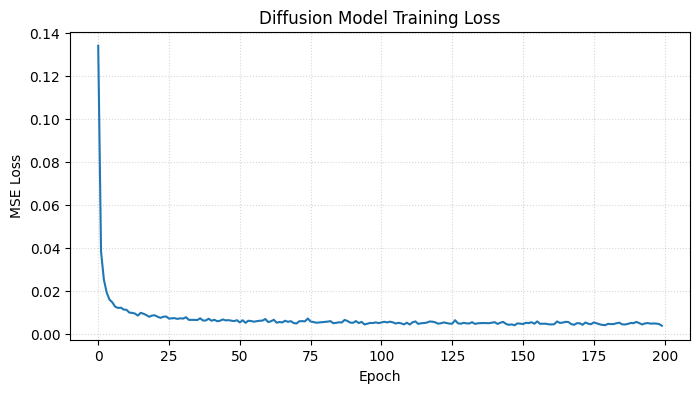

In [ ]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import time

EPOCHS = 200
BATCH_SIZE = 32
LR = 2e-4

dataset = TensorDataset(dataset_tensor)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

loss_history = []
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_losses = []
    for (x0_batch,) in loader:
        x0_batch = x0_batch.to(device)
        batch_size = x0_batch.shape[0]

        t = torch.randint(0, schedule.timesteps, (batch_size,), device=device)
        noise = torch.randn_like(x0_batch)
        x_t = schedule.q_sample(x0_batch, t, noise)

        noise_pred = model(x_t, t)
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{EPOCHS}  loss={avg_loss:.4f}  elapsed={elapsed:.1f}s")

torch.save(model.state_dict(), 'diffusion_unet_weights.pt')
torch.save(loss_history, 'loss_history.pt')
print("\nTraining complete. Saved: diffusion_unet_weights.pt, loss_history.pt")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Diffusion Model Training Loss')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

Generated eps_r range: 2.62 - 24.85
Generated sigma range: -0.00019 - 0.04435


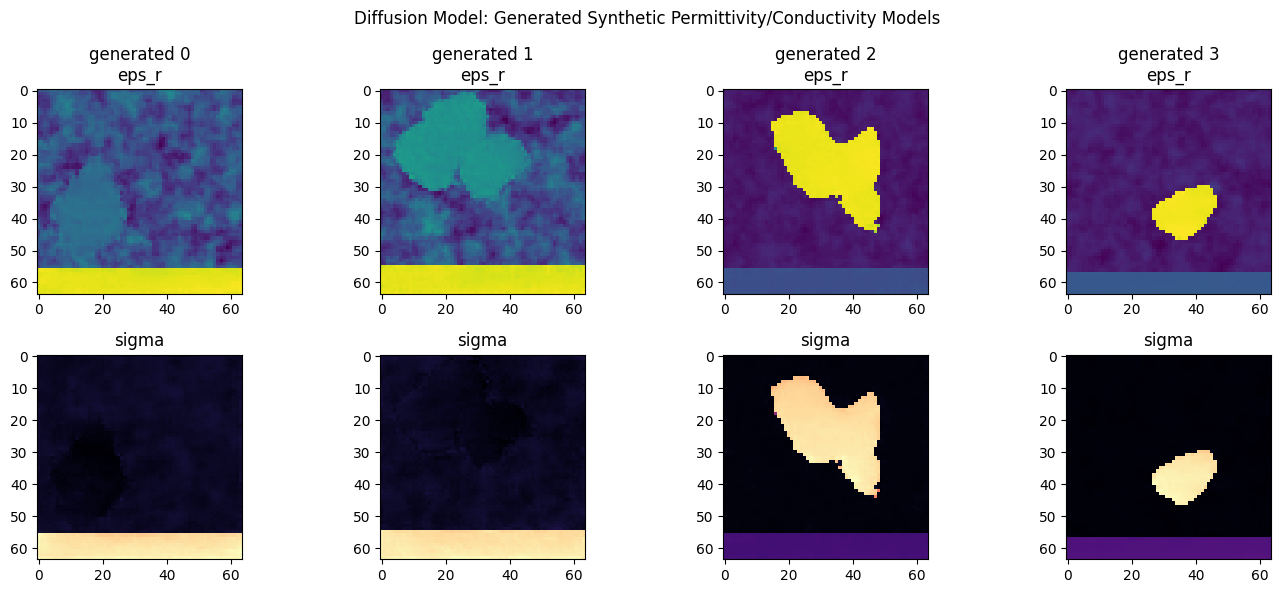

In [ ]:
@torch.no_grad()
def p_sample_loop(model, schedule, shape, device):
    """Standard DDPM ancestral sampling: start from pure noise, iteratively denoise."""
    model.eval()
    x = torch.randn(shape, device=device)
    for t_idx in reversed(range(schedule.timesteps)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)
        beta_t = schedule.betas[t_idx]
        alpha_t = schedule.alphas[t_idx]
        alpha_bar_t = schedule.alphas_cumprod[t_idx]

        predicted_noise = model(x, t)
        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x - coef * predicted_noise)

        if t_idx > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mean + sigma_t * noise
        else:
            x = mean
    model.train()
    return x

def denormalize(x, lo, hi):
    return (x + 1) / 2 * (hi - lo) + lo

# Generate 4 new samples from pure noise
N_GEN = 4
generated = p_sample_loop(model, schedule, (N_GEN, 2, 64, 64), device)

eps_gen = denormalize(generated[:, 0].cpu().numpy(), EPS_MIN, EPS_MAX)
sig_gen = denormalize(generated[:, 1].cpu().numpy(), SIG_MIN, SIG_MAX)

print(f"Generated eps_r range: {eps_gen.min():.2f} - {eps_gen.max():.2f}")
print(f"Generated sigma range: {sig_gen.min():.5f} - {sig_gen.max():.5f}")

fig, axes = plt.subplots(2, N_GEN, figsize=(14, 6))
for col in range(N_GEN):
    axes[0, col].imshow(eps_gen[col], cmap='viridis')
    axes[0, col].set_title(f'generated {col}\neps_r')
    axes[1, col].imshow(sig_gen[col], cmap='magma')
    axes[1, col].set_title('sigma')
plt.suptitle('Diffusion Model: Generated Synthetic Permittivity/Conductivity Models')
plt.tight_layout()
plt.show()

Generated eps_r range: 2.26 - 22.42
Generated sigma range: 0.00010 - 0.01981


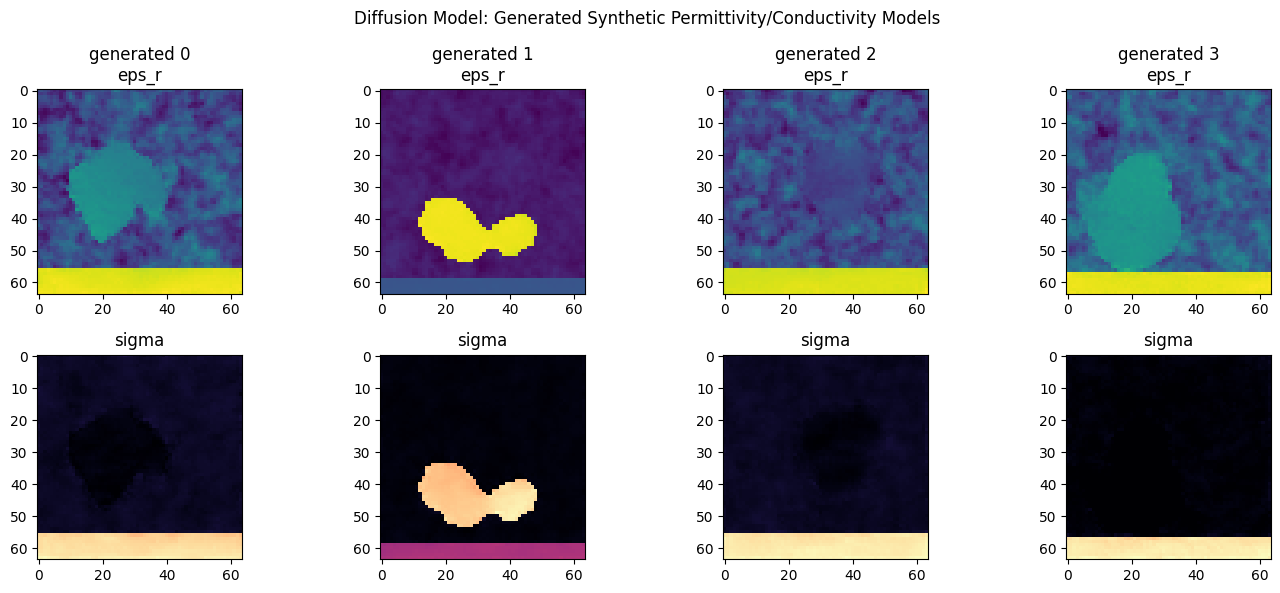

In [ ]:
@torch.no_grad()
def p_sample_loop(model, schedule, shape, device):
    """Standard DDPM ancestral sampling: start from pure noise, iteratively denoise."""
    model.eval()
    x = torch.randn(shape, device=device)
    for t_idx in reversed(range(schedule.timesteps)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)
        beta_t = schedule.betas[t_idx]
        alpha_t = schedule.alphas[t_idx]
        alpha_bar_t = schedule.alphas_cumprod[t_idx]

        predicted_noise = model(x, t)
        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x - coef * predicted_noise)

        if t_idx > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mean + sigma_t * noise
        else:
            x = mean
    model.train()
    return x

def denormalize(x, lo, hi):
    return (x + 1) / 2 * (hi - lo) + lo

# Generate 4 new samples from pure noise
N_GEN = 4
generated = p_sample_loop(model, schedule, (N_GEN, 2, 64, 64), device)

eps_gen = denormalize(generated[:, 0].cpu().numpy(), EPS_MIN, EPS_MAX)
sig_gen = denormalize(generated[:, 1].cpu().numpy(), SIG_MIN, SIG_MAX)

# Clamp to physically valid bounds -- the reverse diffusion process can
# slightly overshoot the training range (e.g. a tiny negative sigma),
# which isn't physically meaningful and should be corrected post-hoc.
eps_gen = np.clip(eps_gen, EPS_MIN, EPS_MAX)
sig_gen = np.clip(sig_gen, SIG_MIN, SIG_MAX)

print(f"Generated eps_r range: {eps_gen.min():.2f} - {eps_gen.max():.2f}")
print(f"Generated sigma range: {sig_gen.min():.5f} - {sig_gen.max():.5f}")

fig, axes = plt.subplots(2, N_GEN, figsize=(14, 6))
for col in range(N_GEN):
    axes[0, col].imshow(eps_gen[col], cmap='viridis')
    axes[0, col].set_title(f'generated {col}\neps_r')
    axes[1, col].imshow(sig_gen[col], cmap='magma')
    axes[1, col].set_title('sigma')
plt.suptitle('Diffusion Model: Generated Synthetic Permittivity/Conductivity Models')
plt.tight_layout()
plt.show()

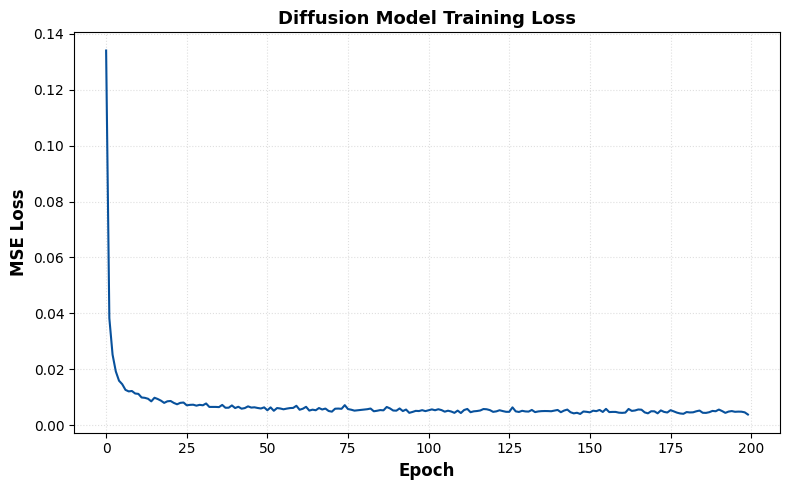

Saved: figure3_panel_training_loss.png


In [ ]:
import torch
import matplotlib.pyplot as plt

loss_history = torch.load('loss_history.pt')

plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='#08519c', linewidth=1.5)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('MSE Loss', fontsize=12, fontweight='bold')
plt.title('Diffusion Model Training Loss', fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('figure3_panel_training_loss.png', dpi=300)
plt.show()
print("Saved: figure3_panel_training_loss.png")

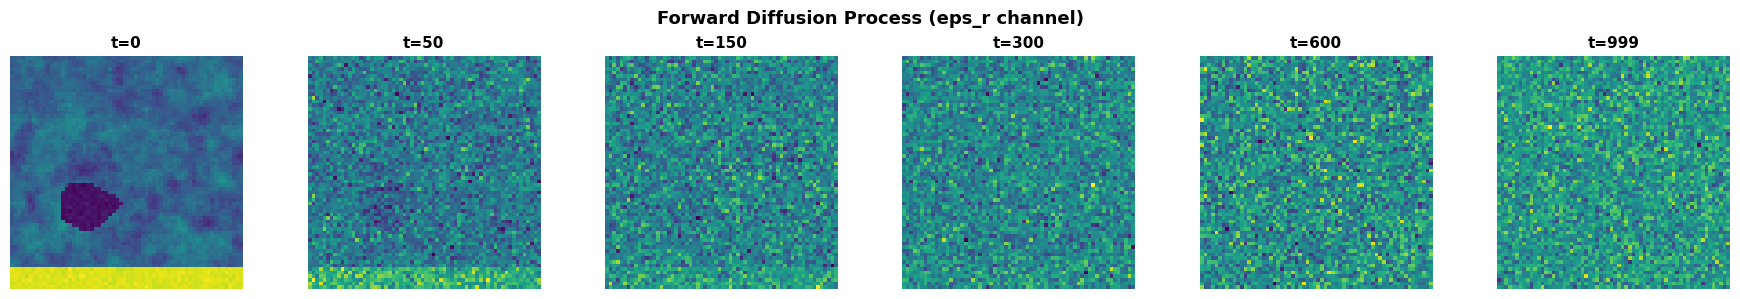

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset_tensor = torch.load('gpr_synthetic_dataset.pt').to(device)
schedule = DiffusionSchedule(timesteps=1000, device=device)

x0 = dataset_tensor[0:1]
check_timesteps = [0, 50, 150, 300, 600, 999]

fig, axes = plt.subplots(1, len(check_timesteps), figsize=(18, 3))
for i, t_val in enumerate(check_timesteps):
    t = torch.tensor([t_val], device=device)
    x_t = schedule.q_sample(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap='viridis')
    axes[i].set_title(f't={t_val}', fontsize=11, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Forward Diffusion Process (eps_r channel)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_panel_forward_diffusion.png', dpi=300)
plt.show()

from google.colab import files
files.download('figure3_panel_forward_diffusion.png')

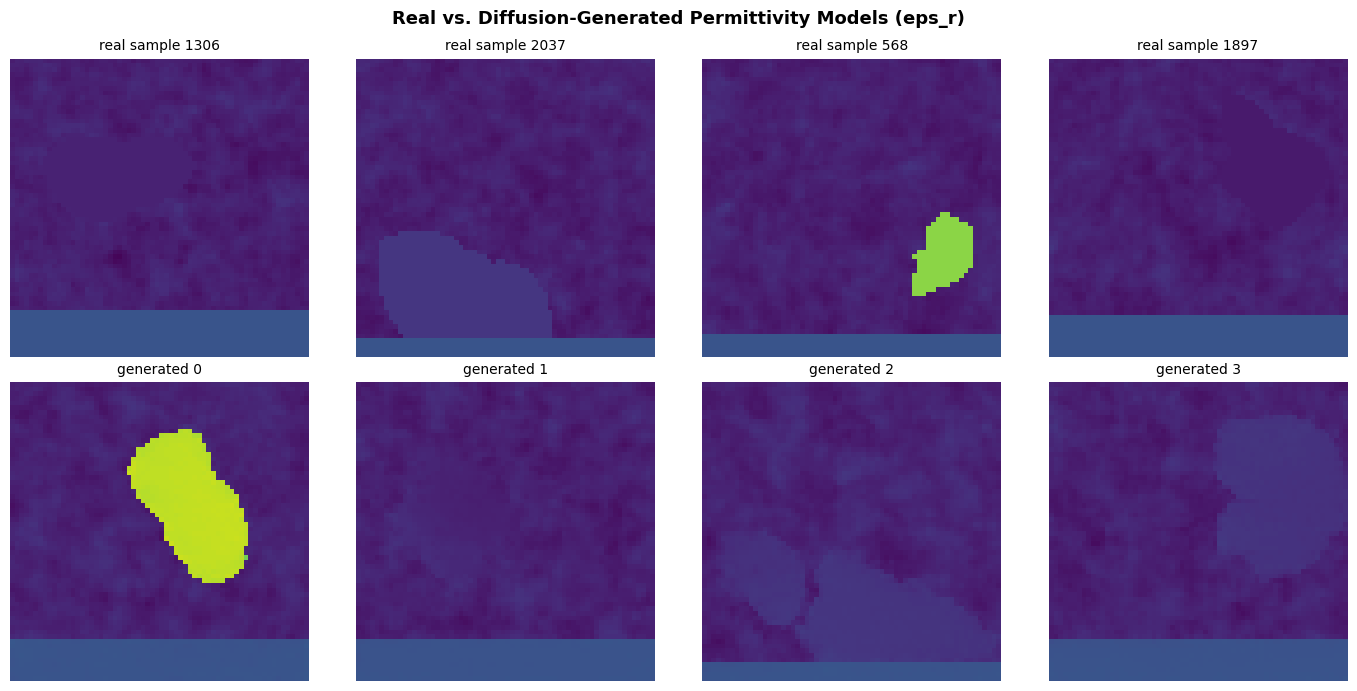

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Real samples: pick 4 at random from the training set, denormalize back to physical units
np.random.seed(7)
real_idxs = np.random.choice(dataset_tensor.shape[0], 4, replace=False)
eps_real = denormalize(dataset_tensor[real_idxs, 0].cpu().numpy(), EPS_MIN, EPS_MAX)

# Generated samples: fresh draw from the trained model
generated = p_sample_loop(model, schedule, (4, 2, 64, 64), device)
eps_gen = denormalize(generated[:, 0].cpu().numpy(), EPS_MIN, EPS_MAX)
eps_gen = np.clip(eps_gen, EPS_MIN, EPS_MAX)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col in range(4):
    axes[0, col].imshow(eps_real[col], cmap='viridis', vmin=EPS_MIN, vmax=EPS_MAX)
    axes[0, col].set_title(f'real sample {real_idxs[col]}', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(eps_gen[col], cmap='viridis', vmin=EPS_MIN, vmax=EPS_MAX)
    axes[1, col].set_title(f'generated {col}', fontsize=10)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Real (training data)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Generated (diffusion model)', fontsize=11, fontweight='bold')
plt.suptitle('Real vs. Diffusion-Generated Permittivity Models (eps_r)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_panel_real_vs_generated.png', dpi=300)
plt.show()

from google.colab import files
files.download('figure3_panel_real_vs_generated.png')

In [1]:
import os
print(os.path.exists('gpr_synthetic_dataset.pt'))
print(os.path.exists('diffusion_unet_weights.pt'))

False
False


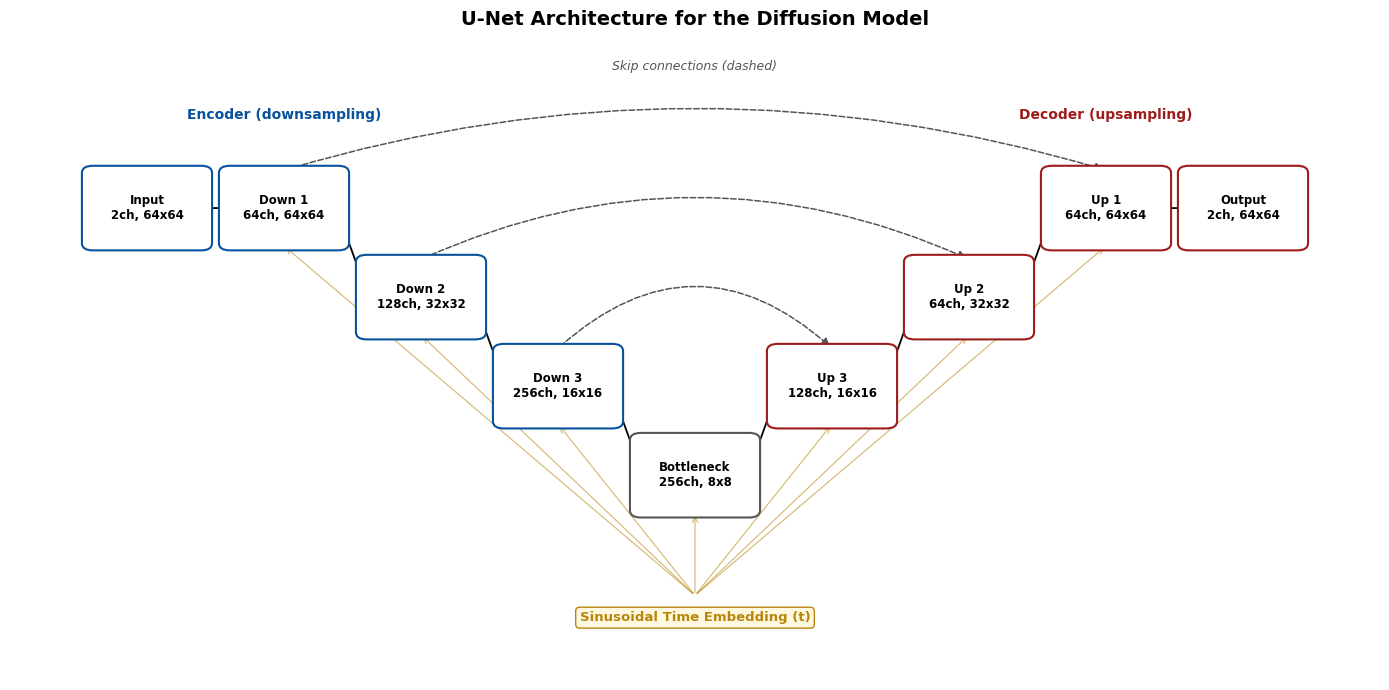

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 7))

blocks = [
    ("Input\n2ch, 64x64",        0, 4),
    ("Down 1\n64ch, 64x64",      1, 4),
    ("Down 2\n128ch, 32x32",     2, 3),
    ("Down 3\n256ch, 16x16",     3, 2),
    ("Bottleneck\n256ch, 8x8",   4, 1),
    ("Up 3\n128ch, 16x16",       5, 2),
    ("Up 2\n64ch, 32x32",        6, 3),
    ("Up 1\n64ch, 64x64",        7, 4),
    ("Output\n2ch, 64x64",       8, 4),
]

box_w, box_h = 0.85, 0.85
positions = {}

for label, x, y in blocks:
    color = '#08519c' if 'Down' in label or 'Input' in label else \
            '#9e1b1b' if 'Up' in label or 'Output' in label else '#555555'
    box = FancyBboxPatch((x - box_w/2, y - box_h/2), box_w, box_h,
                          boxstyle="round,pad=0.05,rounding_size=0.08",
                          linewidth=1.5, edgecolor=color, facecolor='white', zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, fontweight='bold', zorder=4)
    positions[label] = (x, y)

flow_order = [b[0] for b in blocks]
for i in range(len(flow_order) - 1):
    x1, y1 = positions[flow_order[i]]
    x2, y2 = positions[flow_order[i + 1]]
    arrow = FancyArrowPatch((x1 + box_w/2*0.9, y1), (x2 - box_w/2*0.9, y2),
                             arrowstyle='-|>', mutation_scale=14,
                             color='black', linewidth=1.3, zorder=2,
                             connectionstyle="arc3,rad=0.0")
    ax.add_patch(arrow)

skip_pairs = [("Down 1\n64ch, 64x64", "Up 1\n64ch, 64x64"),
              ("Down 2\n128ch, 32x32", "Up 2\n64ch, 32x32"),
              ("Down 3\n256ch, 16x16", "Up 3\n128ch, 16x16")]

for src, dst in skip_pairs:
    x1, y1 = positions[src]
    x2, y2 = positions[dst]
    distance = abs(x2 - x1)
    rad = 0.9 / distance
    arrow = FancyArrowPatch((x1, y1 + box_h/2), (x2, y2 + box_h/2),
                             arrowstyle='-|>', mutation_scale=12,
                             color='#555555', linewidth=1.1, linestyle='--',
                             zorder=1, connectionstyle=f"arc3,rad={-rad}")
    ax.add_patch(arrow)

ax.text(4, -0.6, "Sinusoidal Time Embedding (t)", ha='center', va='center',
        fontsize=9.5, fontweight='bold', color='#b8860b',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8e1', edgecolor='#b8860b'))
for label, x, y in blocks[1:-1]:
    ax.annotate('', xy=(x, y - box_h/2), xytext=(4, -0.35),
                arrowprops=dict(arrowstyle='->', color='#b8860b', lw=0.8,
                                 connectionstyle="arc3,rad=0.0", alpha=0.6), zorder=0)

ax.text(1, 5.0, "Encoder (downsampling)", ha='center', fontsize=10, color='#08519c', fontweight='bold')
ax.text(7, 5.0, "Decoder (upsampling)", ha='center', fontsize=10, color='#9e1b1b', fontweight='bold')
ax.text(4, 5.55, "Skip connections (dashed)", ha='center', fontsize=9, color='#555555', style='italic')

ax.set_xlim(-1, 9)
ax.set_ylim(-1.3, 5.9)
ax.axis('off')
ax.set_title('U-Net Architecture for the Diffusion Model', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('figure3_panel_unet_architecture.png', dpi=300)
plt.show()

from google.colab import files
files.download('figure3_panel_unet_architecture.png')